# 05 — Ongoing monitoring: is the model still working?

This notebook builds the monitoring that watches the valuation model after launch, then tests
it against a population it should reject (§5). It scores the frozen champion from notebook 03
quarter by quarter on the 2009–2010 production period, tracking input drift, score drift,
accuracy and interval coverage against limits set in advance. Every control stays inside its
limit on the live book, five of the six fire on non-arm's-length sales, and rolling
recalibration of the interval lifts out-of-time coverage from 76.7% to 78.8%.

Terms are defined in [the glossary](../docs/GLOSSARY.md).

The framework is **SR 11-7**, the Federal Reserve and OCC guidance on how banks must manage
the models they rely on. It divides validation into three parts:

| | What it asks | Where this project does it |
|---|---|---|
| **Conceptual soundness** | Is the design defensible? | [`docs/METHODOLOGY.md`](../docs/METHODOLOGY.md) |
| **Outcomes analysis** | Do the answers match reality? | Notebooks 03 and 04 |
| **Ongoing monitoring** | Is it *still* working? | **This notebook** |

Most analysis projects stop after the first two, because the third only becomes
relevant once a model is live.

In [1]:
import json
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone

from ames.avm import (ConformalValuation, duan_smearing_factor, mdape,
                      mean_signed_error, ppe)
from ames.compat import silence_spurious_matmul_warnings, worker_warning_filter
from ames.config import ARMS_LENGTH_CONDITION, CONFORMAL_ALPHA, PROCESSED, SEED
from ames.data import load_properties
from ames.features import prepare, split_feature_types
from ames.monitoring import (DETERMINISTIC_TIME_FEATURES, MonitoringThresholds,
                             PSI_SIGNIFICANT, PSI_STABLE, accuracy_by_period, any_breach,
                             champion_challenger, evaluate_triggers, feature_drift,
                             population_stability_index, promotion_decision, psi_label)
from ames.viz import (AQUA, BLUE, CATEGORICAL_3, CONTEXT, CONTEXT_DARK, CONTRAST,
                      CONTRAST_FILL, DIVERGING, GRID, INK_MUTED, INK_SECONDARY,
                      ORANGE, PANEL, SEQUENTIAL, STATUS, SUBJECT, SUBJECT_FILL,
                      SURFACE, VIOLET, annotate, axis_note, band, bar_labels,
                      callout, dumbbell, emphasise, era, fig_titled, hero,
                      label_end, legend_above, money, pct, pct1, reference_line,
                      save, titled, use_style)

use_style()

silence_spurious_matmul_warnings()
os.environ["PYTHONWARNINGS"] = worker_warning_filter()
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

# The figure furniture every chart in this notebook shares: which notebook you are in,
# and where the numbers came from.  Defined once so the nine notebooks read as one report.
KICKER = "05 · Monitoring"
SOURCE = "Source: De Cock (2011) · champion model frozen at end-2008, scored quarterly."

def finish(fig, headline, standfirst=None, source=SOURCE):
    """Add the editorial title block and source note."""
    fig_titled(fig, headline, standfirst, kicker=KICKER, source=source)

artifacts = joblib.load(PROCESSED / "avm_model.joblib")
data = prepare(load_properties())
universe = data[(data["Sale Condition"] == ARMS_LENGTH_CONDITION)
                & (~data["is_outlier_grlivarea"])].copy()
numeric, nominal = split_feature_types(universe)

development = universe[universe["temporal_split"] == "train"]     # 2006-2008
production = universe[universe["temporal_split"] == "test"].copy()  # 2009 - Jul 2010
production["quarter"] = production["sale_date"].dt.to_period("Q").astype(str)

print(f"development sample (what the model learned from): {len(development):,} sales, "
      f"{development['Yr Sold'].min():.0f}-{development['Yr Sold'].max():.0f}")
print(f"production sample (what it was then asked to value): {len(production):,} sales "
      f"across {production['quarter'].nunique()} quarters")

development sample (what the model learned from): 1,550 sales, 2006-2008
production sample (what it was then asked to value): 862 sales across 7 quarters


## 1. The champion model

The model from notebook 03 is frozen. In production a model is
not retrained ad hoc whenever it slips. It runs unchanged until a trigger (a limit set in
advance) is breached and a rebuild is formally approved.

In [2]:
champion = clone(artifacts["estimator"])
y_dev = np.log(development["SalePrice"])
champion.fit(development, y_dev)
log_smear = np.log(duan_smearing_factor(y_dev - champion.predict(development)))

def value(df) -> np.ndarray:
    """Champion valuations in dollars."""
    return np.exp(champion.predict(df) + log_smear)

production["predicted"] = value(production)
production["log_pred"] = np.log(production["predicted"])

# Conformal interval calibrated once, at launch, on held-out development rows.
from ames.avm import split_calibration
proper_idx, calib_idx = split_calibration(development.index, 0.5, SEED)
calibration_model = clone(artifacts["estimator"]).fit(
    universe.loc[proper_idx], np.log(universe.loc[proper_idx, "SalePrice"]))
calib_smear = np.log(duan_smearing_factor(
    np.log(universe.loc[proper_idx, "SalePrice"]) - calibration_model.predict(universe.loc[proper_idx])))
launch_interval = ConformalValuation(CONFORMAL_ALPHA).calibrate(
    np.log(universe.loc[calib_idx, "SalePrice"]),
    calibration_model.predict(universe.loc[calib_idx]) + calib_smear)

print(f"champion frozen at launch · conformal half-width q = {launch_interval.q_:.4f}")

champion frozen at launch · conformal half-width q = 0.1048


## 2. Are the inputs drifting?

Before asking whether the answers are wrong, monitoring asks whether the model is still
being asked the same question. If the homes arriving for valuation stop resembling
the homes the model learned from, accuracy will follow, usually later, by which point
the damage is done.

The Population Stability Index (PSI) compares each quarter's incoming properties against the
development sample in a single number: below 0.10 is conventionally read as the same
population, above 0.25 as meaningfully different. Two guards have to go in first, and both
were found by building this and looking at the output rather than by reasoning about it in
advance.

### Guard 1: never monitor a feature that changes by definition

`sale_time` scores a PSI of **11.3** every single quarter. That is not drift. Under a
temporal split the sale date cannot overlap between a 2006–2008 training window and
a 2009–2010 scoring window, because the split is defined that way. `Mo Sold` and the
seasonality terms behave the same: a quarter holds three months, a year holds twelve,
so a quarter always looks like a shift.

A control that is permanently red trains people to ignore it, so these features are excluded
by name in `monitoring.py`.

In [3]:
example = population_stability_index(development["sale_time"], production["sale_time"],
                                     min_sample=0)
print(f"PSI of 'sale_time', if we were foolish enough to monitor it: {example:.2f}")
print(f"excluded by construction: {sorted(DETERMINISTIC_TIME_FEATURES)}")

PSI of 'sale_time', if we were foolish enough to monitor it: 11.32
excluded by construction: ['Mo Sold', 'Yr Sold', 'month_cos', 'month_sin', 'sale_time']


### Guard 2: PSI is not scale-free in sample size

2010Q3 holds only 8 sales (the data stops in July 2010). With ten
bins and eight observations, almost every bin is empty and PSI reports an enormous
shift that is entirely sampling noise.

In [4]:
tiny = production[production["quarter"] == "2010Q3"]
print(f"2010Q3 holds {len(tiny)} sales")
print(f"  unguarded PSI on Gr Liv Area: "
      f"{population_stability_index(development['Gr Liv Area'], tiny['Gr Liv Area'], min_sample=0):.2f}"
      f"   <- pure noise, reads as a catastrophe")
print(f"  guarded PSI:                  "
      f"{population_stability_index(development['Gr Liv Area'], tiny['Gr Liv Area'])}"
      f"      <- not measurable, and says so")

2010Q3 holds 8 sales
  unguarded PSI on Gr Liv Area: 7.55   <- pure noise, reads as a catastrophe
  guarded PSI:                  nan      <- not measurable, and says so


The rule applied throughout is roughly ten expected observations per bin. Because
the quarters here run 79–208 sales, monitoring uses 5 bins rather than 10: less
resolution, but a real measurement instead of a spurious alarm.

In [5]:
BINS = 5
drift_frames = []
for quarter, rows in production.groupby("quarter"):
    d = feature_drift(development, rows, numeric=numeric, nominal=nominal, bins=BINS)
    d["quarter"] = quarter
    drift_frames.append(d)
drift = pd.concat(drift_frames, ignore_index=True)
measurable = drift.dropna(subset=["psi"])
print(f"quarters with enough sales to measure drift: "
      f"{sorted(measurable['quarter'].unique())}")

worst = (measurable.groupby("feature")["psi"].max()
         .sort_values(ascending=False).head(12).rename("worst quarterly PSI"))
worst.to_frame().assign(reading=lambda d: d["worst quarterly PSI"].map(psi_label)).round(4)

quarters with enough sales to measure drift: ['2009Q1', '2009Q2', '2009Q3', '2009Q4', '2010Q1', '2010Q2']


,worst quarterly PSI,reading
feature,,
Neighborhood,0.9675,significant shift
Exterior 2nd,0.6365,significant shift
MS SubClass,0.6064,significant shift
Exterior 1st,0.4612,significant shift
Condition 1,0.4552,significant shift
Bldg Type,0.3290,significant shift
House Style,0.3253,significant shift
Land Contour,0.2561,significant shift
Mas Vnr Type,0.2003,moderate shift


  saved reports/figures/05_input_drift.png


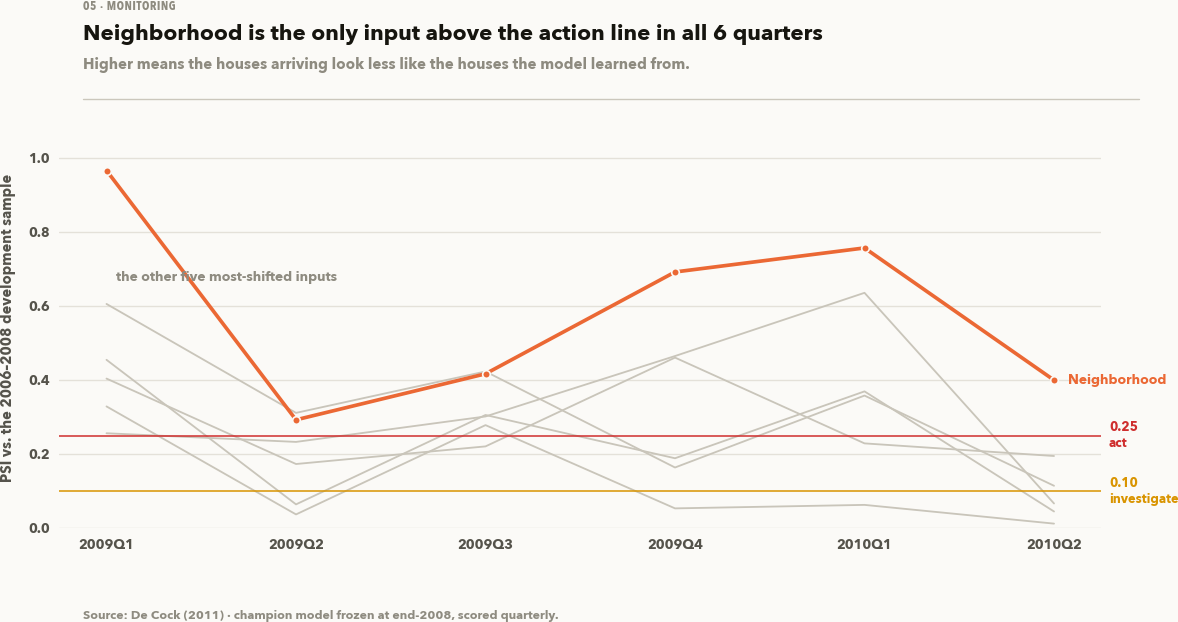

In [6]:
top_features = worst.head(6).index
pivot = measurable[measurable["feature"].isin(top_features)].pivot(
    index="quarter", columns="feature", values="psi")

# One line picked out, the rest recessive.  Six categorical hues crossing each other is
# a chart nobody reads; the finding concerns a single feature, so colour is spent on
# emphasis rather than identity.
worst_feature = worst.index[0]
fig, ax = plt.subplots(figsize=(11.0, 6.2))
emphasise(ax, list(pivot.index), {c: pivot[c].to_numpy() for c in pivot.columns},
          highlight=worst_feature)
reference_line(ax, PSI_STABLE, "0.10\ninvestigate", color=STATUS["warning"])
reference_line(ax, PSI_SIGNIFICANT, "0.25\nact", color=STATUS["critical"])
ax.set_ylabel("PSI vs. the 2006–2008 development sample")
ax.set_ylim(0, max(pivot.to_numpy().max() * 1.12, PSI_SIGNIFICANT * 1.3))
annotate(ax, 0, pivot.drop(columns=worst_feature).to_numpy().max(),
         "the other five most-shifted inputs", color=INK_MUTED, offset=(6, 10))
above = int((pivot[worst_feature] > PSI_SIGNIFICANT).sum())
finish(fig, f"{worst_feature} is the only input above the action line in all "
           f"{above} quarters",
       "Higher means the houses arriving look less like the houses the model learned from.")
save(fig, "05_input_drift")
plt.show()

## 3. Is the *score* drifting?

Inputs can move in offsetting directions and leave the output unchanged, or sit still
while the output wanders. Both are worth knowing, so the valuations themselves are
monitored as their own distribution.

In [7]:
dev_scores = value(development)
score_psi = {q: population_stability_index(dev_scores, rows["predicted"], bins=BINS)
             for q, rows in production.groupby("quarter")}
score_drift = pd.Series(score_psi, name="score PSI").to_frame()
score_drift["reading"] = score_drift["score PSI"].map(psi_label)
score_drift["median valuation"] = production.groupby("quarter")["predicted"].median()
score_drift.round(4)

,score PSI,reading,median valuation
2009Q1,0.0453,stable,161972.0268
2009Q2,0.0353,stable,170119.5032
2009Q3,0.0248,stable,159187.7793
2009Q4,0.1828,moderate shift,160314.9619
2010Q1,0.0169,stable,166427.2256
2010Q2,0.0161,stable,153911.3489
2010Q3,NaN,undefined,142083.5359


## 4. Is accuracy decaying?

This is the most important measurement and the last to arrive, because it needs the true
sale price, which in practice lands weeks or months after the valuation.

In [8]:
accuracy = accuracy_by_period(production["actual"] if "actual" in production
                              else production["SalePrice"],
                              production["predicted"], production["quarter"], min_n=30)
accuracy["coverage"] = [
    launch_interval.coverage(np.log(g["SalePrice"]), g["log_pred"])
    for _, g in production.groupby("quarter") if len(g) >= 30]
accuracy["score_psi"] = accuracy["period"].map(score_psi)
accuracy["max_feature_psi"] = accuracy["period"].map(
    measurable.groupby("quarter")["psi"].max())
accuracy.round(4)

,period,n,MdAPE,PPE10,mean_signed_error,median_actual,coverage,score_psi,max_feature_psi
0,2009Q1,79,0.0566,0.7468,0.0048,167000.0,0.7595,0.0453,0.9675
1,2009Q2,200,0.0539,0.7850,0.0079,170500.0,0.7900,0.0353,0.3115
2,2009Q3,184,0.0436,0.7880,-0.0117,159250.0,0.8152,0.0248,0.4236
3,2009Q4,98,0.0620,0.7347,0.0116,153500.0,0.7449,0.1828,0.6929
4,2010Q1,85,0.0570,0.7412,-0.0143,162500.0,0.7412,0.0169,0.7579
5,2010Q2,208,0.0543,0.7596,-0.0063,155000.0,0.7596,0.0161,0.4002


  saved reports/figures/05_accuracy_decay.png


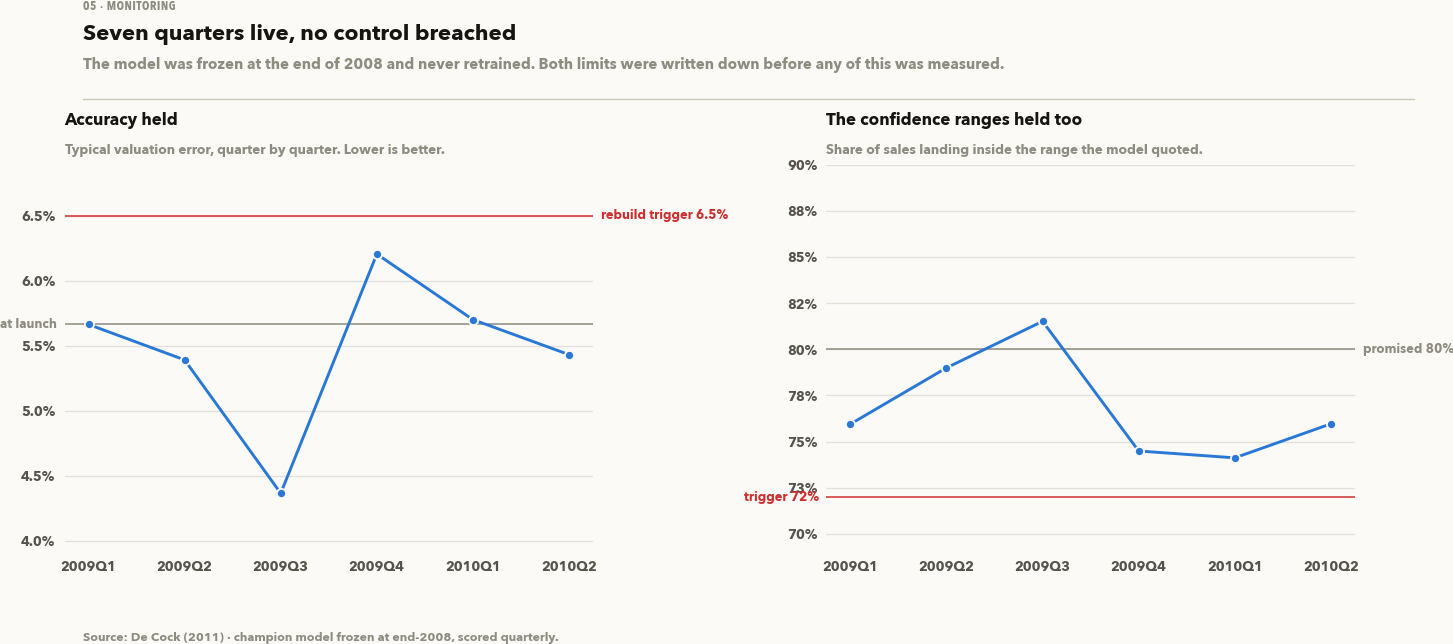

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.4))
t = MonitoringThresholds()

ax = axes[0]
ax.plot(accuracy["period"], accuracy["MdAPE"], color=SUBJECT, marker="o", markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1.2)
reference_line(ax, t.mdape_limit, f"rebuild trigger {t.mdape_limit:.1%}",
               color=STATUS["critical"])
reference_line(ax, accuracy["MdAPE"].iloc[0], "at launch", color=INK_MUTED, side="left")
ax.yaxis.set_major_formatter(pct1)
# Zoomed to the data plus the trigger: a zero baseline would put the whole story in
# the top fifth of the panel.
ax.set_ylim(accuracy["MdAPE"].min() * 0.90, t.mdape_limit * 1.06)
titled(ax, "Accuracy held", "Typical valuation error, quarter by quarter. Lower is better.")

ax = axes[1]
ax.plot(accuracy["period"], accuracy["coverage"], color=SUBJECT, marker="o", markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=1.2)
reference_line(ax, 1 - CONFORMAL_ALPHA, "promised 80%", color=INK_MUTED)
reference_line(ax, t.coverage_floor, f"trigger {t.coverage_floor:.0%}",
               color=STATUS["critical"], side="left")
ax.yaxis.set_major_formatter(pct)
ax.set_ylim(t.coverage_floor * 0.96, 0.90)
titled(ax, "The confidence ranges held too",
       "Share of sales landing inside the range the model quoted.")

finish(fig, "Seven quarters live, no control breached",
       "The model was frozen at the end of 2008 and never retrained. Both limits were "
       "written down before any of this was measured.")
save(fig, "05_accuracy_decay")
plt.show()

## 5. Does the alarm work?

Every control above is inside its limit, which on its own cannot distinguish a stable model
from a monitor that is not working. Notebook 02 explains why the controls should be quiet
here: Ames fell 4.3% peak-to-trough against 27.4% nationally, so 2009–2010 was not much of a
regime change.

The controls are therefore tested against a population they should reject: the 517
non-arm's-length sales excluded in notebook 03. Foreclosures, family transfers and
unfinished new-builds are a different population, and monitoring that cannot detect that
difference is not useful.

In [10]:
negative_control = data[(data["Sale Condition"] != ARMS_LENGTH_CONDITION)].copy()
negative_control["predicted"] = value(negative_control)
negative_control["log_pred"] = np.log(negative_control["predicted"])

control_drift = feature_drift(development, negative_control, numeric=numeric,
                              nominal=nominal, bins=BINS)

def snapshot(rows: pd.DataFrame, drift_table: pd.DataFrame) -> dict[str, float]:
    return {
        "MdAPE": mdape(rows["SalePrice"], rows["predicted"]),
        "PPE10": ppe(rows["SalePrice"], rows["predicted"], 0.10),
        "mean_signed_error": mean_signed_error(rows["SalePrice"], rows["predicted"]),
        "score_psi": population_stability_index(dev_scores, rows["predicted"], bins=BINS),
        "max_feature_psi": float(np.nanmax(drift_table["psi"])),
        "coverage": launch_interval.coverage(np.log(rows["SalePrice"]), rows["log_pred"]),
    }

live = snapshot(production, feature_drift(development, production, numeric=numeric,
                                          nominal=nominal, bins=BINS))
alarm = snapshot(negative_control, control_drift)

comparison = pd.DataFrame({
    "live arm's-length book": live,
    "non-market sales (should trip)": alarm,
}).T
comparison.round(4)

,MdAPE,PPE10,mean_signed_error,score_psi,max_feature_psi,coverage
live arm's-length book,0.0549,0.7657,-0.0011,0.0054,0.0939,0.7749
non-market sales (should trip),0.0820,0.5764,0.0638,0.1929,0.7946,0.5841


In [11]:
live_triggers = evaluate_triggers(live)
alarm_triggers = evaluate_triggers(alarm)

dashboard = live_triggers.merge(alarm_triggers, on=["control", "limit", "breach_if"],
                                suffixes=(" · live", " · non-market"))
print(f"live book        -> {'BREACH' if any_breach(live_triggers) else 'all controls within limits'}")
print(f"non-market sales -> {'BREACH' if any_breach(alarm_triggers) else 'NO BREACH (the alarm is broken)'}"
      f"  [{int(alarm_triggers['breached'].eq(True).sum())} of {len(alarm_triggers)} controls]")
dashboard.round(4)

live book        -> all controls within limits
non-market sales -> BREACH  [5 of 6 controls]


,control,observed · live,limit,breach_if,breached · live,observed · non-market,breached · non-market
0,Accuracy: MdAPE,0.0549,0.065,above,False,0.0820,True
1,Accuracy: PPE10,0.7657,0.720,below,False,0.5764,True
2,Bias: |mean signed error|,0.0011,0.020,above,False,0.0638,True
3,Score stability: PSI,0.0054,0.250,above,False,0.1929,False
4,Input stability: worst feature PSI,0.0939,0.250,above,False,0.7946,True
5,Interval coverage,0.7749,0.720,below,False,0.5841,True


  saved reports/figures/05_trigger_dashboard.png


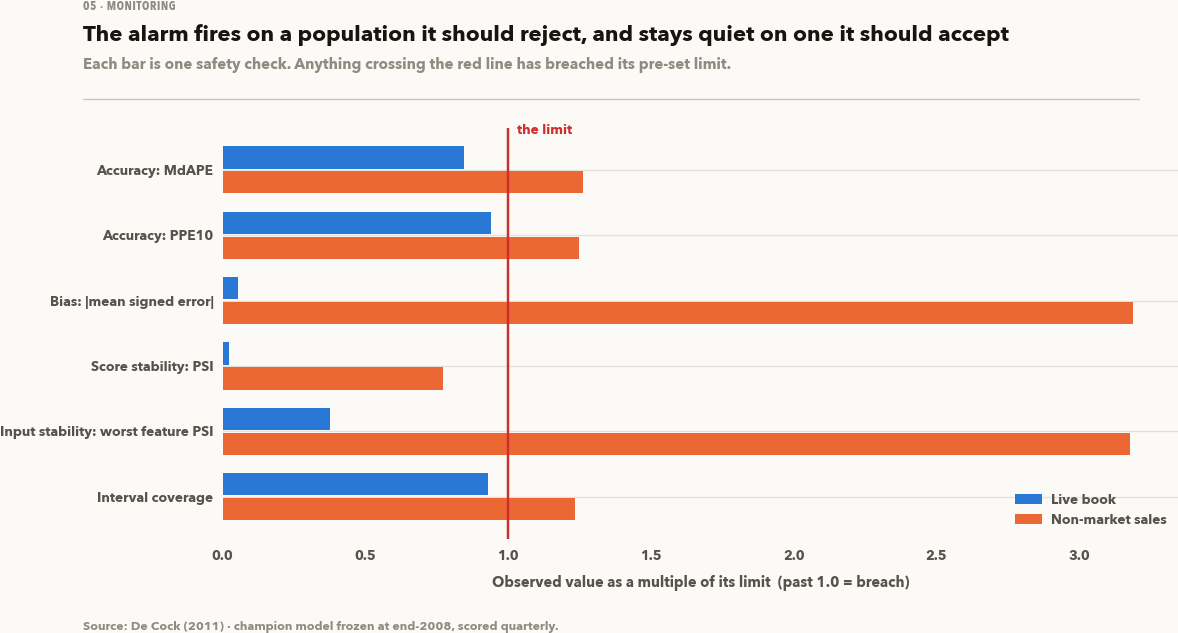

In [12]:
fig, ax = plt.subplots(figsize=(11.0, 6.3))
controls = live_triggers["control"]
y = np.arange(len(controls))[::-1]
for i, (_, row) in enumerate(live_triggers.iterrows()):
    a = alarm_triggers.iloc[i]
    # Normalise each control onto "how far past its limit", so six different units
    # can share one axis honestly.
    def ratio(obs, lim, direction):
        if obs is None or not np.isfinite(obs) or lim == 0:
            return np.nan
        return obs / lim if direction == "above" else lim / obs
    ax.barh(y[i] + 0.19, ratio(row["observed"], row["limit"], row["breach_if"]),
            height=0.34, color=BLUE, label="Live book" if i == 0 else None)
    ax.barh(y[i] - 0.19, ratio(a["observed"], a["limit"], a["breach_if"]),
            height=0.34, color=ORANGE, label="Non-market sales" if i == 0 else None)
ax.axvline(1.0, color=STATUS["critical"], lw=1.6)
annotate(ax, 1.0, len(controls) - 0.4, "the limit", color=STATUS["critical"], offset=(6, 0))
ax.set_yticks(y, controls, fontsize=9)
ax.set_xlabel("Observed value as a multiple of its limit  (past 1.0 = breach)")
ax.legend(loc="lower right")
finish(fig, "The alarm fires on a population it should reject, and stays quiet on one it should accept",
       "Each bar is one safety check. Anything crossing the red line has breached its pre-set limit.")
save(fig, "05_trigger_dashboard")
plt.show()

**Every control sits inside its limit on the live book, and five of the six fire on a
population the model should not be valuing.** Without this test, a suite that never alarms
could not be told apart from one that is disconnected.

Two details stand out.

Score stability is the one control that does not fire. Non-market homes look
structurally like market homes (similar size, age and quality), so the valuations the
model produces for them sit in a normal-looking distribution. What differs is the price
they transact at. Score drift alone would never have caught this contamination, which is
why the pack monitors inputs, scores and outcomes rather than picking one.

Aggregate monitoring smooths over quarterly noise. Measured across the whole
production period the worst input PSI is 0.09, comfortably inside the limit, but the
quarterly panel in §2 shows `Neighborhood` reaching 0.97 in 2009Q1. With 79 sales spread
across 28 neighbourhoods, quarterly composition is inherently unstable. In production
the fix is to monitor high-cardinality categoricals on a rolling four-quarter window
rather than quarter by quarter, so real mix shifts are separated from small-sample
churn.

There is also a practical use: if `Sale Condition` were ever missing
or late in the production feed, these controls would catch the contamination. Notebook
08 builds the model that catches it property by property rather than in aggregate.

## 6. Champion versus challenger

Suppose the model were retrained every quarter on everything known so far. Would it be better?

A bank answers this before promoting a replacement (the *challenger*) over the model in
production (the *champion*), and a better average is not enough. A challenger that wins on
average by winning hugely once and losing three times is more volatile, not safer.

In [13]:
quarters = sorted(production["quarter"].unique())
rows_champion, rows_challenger = [], []

for q in quarters:
    q_rows = production[production["quarter"] == q]
    if len(q_rows) < 30:
        continue
    # Challenger: everything sold strictly before this quarter starts.
    cutoff = pd.Period(q, freq="Q").start_time
    history = universe[universe["sale_date"] < cutoff]
    challenger = clone(artifacts["estimator"])
    y_hist = np.log(history["SalePrice"])
    challenger.fit(history, y_hist)
    smear = np.log(duan_smearing_factor(y_hist - challenger.predict(history)))
    preds = np.exp(challenger.predict(q_rows) + smear)

    rows_champion.append({"period": q, "n": len(q_rows),
                          "MdAPE": mdape(q_rows["SalePrice"], q_rows["predicted"]),
                          "PPE10": ppe(q_rows["SalePrice"], q_rows["predicted"], 0.10)})
    rows_challenger.append({"period": q, "n_train": len(history),
                            "MdAPE": mdape(q_rows["SalePrice"], preds),
                            "PPE10": ppe(q_rows["SalePrice"], preds, 0.10)})

champ_df = pd.DataFrame(rows_champion)
chall_df = pd.DataFrame(rows_challenger)
comparison = champion_challenger(champ_df, chall_df, metric="MdAPE")
comparison[["period", "n", "n_train", "MdAPE_champion", "MdAPE_challenger",
            "improvement", "challenger_wins"]].round(4)

,period,n,n_train,MdAPE_champion,MdAPE_challenger,improvement,challenger_wins
0,2009Q1,79,1550,0.0566,0.0566,0.0000,False
1,2009Q2,200,1629,0.0539,0.0547,-0.0008,False
2,2009Q3,184,1829,0.0436,0.0416,0.0021,True
3,2009Q4,98,2013,0.0620,0.0530,0.0091,True
4,2010Q1,85,2111,0.0570,0.0637,-0.0067,False
5,2010Q2,208,2196,0.0543,0.0531,0.0012,True


{
  "periods_compared": 6,
  "challenger_win_rate": 0.5,
  "mean_improvement": 0.0008250416950638592,
  "promote": false,
  "rule": "promote if the challenger wins in >= 60% of periods and improves the metric on average"
}
  saved reports/figures/05_champion_challenger.png


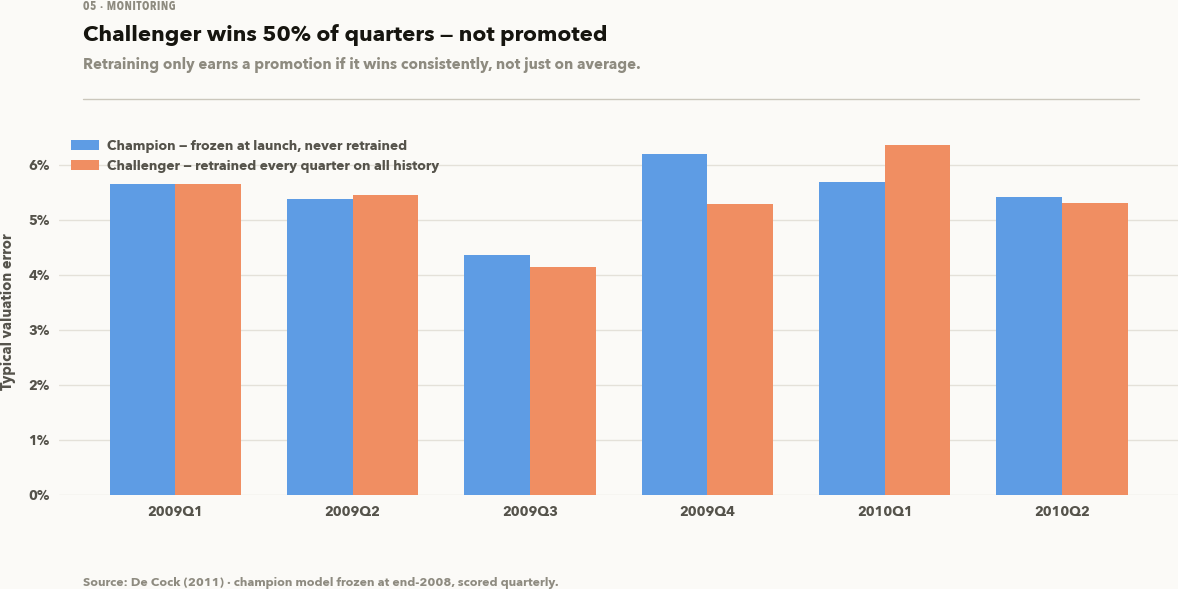

In [14]:
decision = promotion_decision(comparison)
print(json.dumps(decision, indent=2))

fig, ax = plt.subplots(figsize=(11.0, 5.9))
x = np.arange(len(comparison))
w = 0.37
ax.bar(x - w / 2, comparison["MdAPE_champion"], w, color=SUBJECT_FILL,
       label="Champion — frozen at launch, never retrained")
ax.bar(x + w / 2, comparison["MdAPE_challenger"], w, color=CONTRAST_FILL,
       label="Challenger — retrained every quarter on all history")
ax.set_xticks(x, comparison["period"])
ax.yaxis.set_major_formatter(pct)
ax.set_ylabel("Typical valuation error")
ax.legend(loc="upper left")
verdict = "promoted" if decision["promote"] else "not promoted"
finish(fig, f"Challenger wins {decision['challenger_win_rate']:.0%} of quarters — {verdict}",
       "Retraining only earns a promotion if it wins consistently, not just on average.")
save(fig, "05_champion_challenger")
plt.show()

## 7. Rolling recalibration of the interval

§6 asked whether the point model should be retrained, and the answer was no. The
interval is a separate question. Notebook 04 calibrated it once, at launch, on 2006–2008
sales, and out-of-time it covers about 77% of sales against the 80% it promises.

Once a 2009 sale closes, its price is known, and its residual shows how wrong the frozen
model is on the current market, which is the evidence the interval needs. Rolling
recalibration feeds those residuals back. Before each quarter, the Mondrian bands are
re-fitted on the sales that closed in the previous twelve months; the point model
does not change.

The backtest is strict about time. A quarter's valuations are issued with bands built
only from sales that closed before the quarter began, i.e. the ranges a client would
have been shown. The residuals come from the same calibration model as the launch bands
(cell 3), so the two versions differ only in which sales they are calibrated on.

In [15]:
from ames.avm import MondrianConformal

RECAL_WINDOW_MONTHS = 12
MONDRIAN_BINS = 5                    # as notebook 04

# Every sale whose residual may enter a calibration: the launch calibration half of
# 2006-2008, plus each production sale once it has closed.
cal_pool = universe.loc[np.concatenate([calib_idx, production.index])].copy()
cal_pool["log_pred"] = calibration_model.predict(cal_pool) + calib_smear
cal_pool["log_actual"] = np.log(cal_pool["SalePrice"])
cal_pool["quarter"] = cal_pool["sale_date"].dt.to_period("Q")


def mondrian(rows) -> MondrianConformal:
    return MondrianConformal(CONFORMAL_ALPHA, n_bins=MONDRIAN_BINS).calibrate(
        rows["log_actual"], rows["log_pred"])


def trailing_window(before: pd.Timestamp) -> pd.DataFrame:
    """Sales that closed in the twelve months before ``before`` -- and only those."""
    closed = cal_pool[cal_pool["sale_date"] < before]
    return closed[closed["sale_date"] >= before - pd.DateOffset(months=RECAL_WINDOW_MONTHS)]


launch_bands = mondrian(cal_pool.loc[calib_idx])
issued = []
for quarter, rows in cal_pool.loc[production.index].groupby("quarter"):
    window = trailing_window(quarter.start_time)
    for name, bands in (("launch", launch_bands), ("rolling", mondrian(window))):
        q = bands.half_width(rows["log_pred"])
        issued.append(pd.DataFrame({
            "PID": rows["PID"], "quarter": str(quarter), "calibration": name,
            "log_pred": rows["log_pred"], "log_actual": rows["log_actual"], "q": q,
            "band": bands.band(rows["log_pred"]) + 1,
            "covered": np.abs(rows["log_actual"] - rows["log_pred"]) <= q,
            "width": np.exp(q) - np.exp(-q), "window_n": len(window),
        }, index=rows.index))
issued = pd.concat(issued)

by_quarter = issued.pivot_table(index="quarter", columns="calibration",
                                values=["covered", "width"], aggfunc="mean")
by_quarter["n"] = issued[issued["calibration"] == "rolling"].groupby("quarter").size()
by_quarter["window n"] = issued[issued["calibration"] == "rolling"].groupby("quarter")["window_n"].first()

# Paired bootstrap over sales: the same resample scores both calibrations.
launch_hit = issued.loc[issued["calibration"] == "launch", "covered"].to_numpy(float)
rolling_hit = issued.loc[issued["calibration"] == "rolling", "covered"].to_numpy(float)
draws = np.random.default_rng(SEED).integers(0, len(launch_hit), (5000, len(launch_hit)))
gain = rolling_hit[draws].mean(1) - launch_hit[draws].mean(1)
recalibration = {
    "coverage_launch": float(launch_hit.mean()),
    "coverage_rolling": float(rolling_hit.mean()),
    "gain": float(rolling_hit.mean() - launch_hit.mean()),
    "gain_ci": [float(np.percentile(gain, 2.5)), float(np.percentile(gain, 97.5))],
    "width_launch": float(issued.loc[issued["calibration"] == "launch", "width"].mean()),
    "width_rolling": float(issued.loc[issued["calibration"] == "rolling", "width"].mean()),
    "sales_gained": int(((rolling_hit == 1) & (launch_hit == 0)).sum()),
    "sales_lost": int(((rolling_hit == 0) & (launch_hit == 1)).sum()),
    "n": int(len(launch_hit)),
}
print(f"all {recalibration['n']} production sales, each with the range issued at the time:")
print(f"  launch calibration   coverage {recalibration['coverage_launch']:.1%}  "
      f"mean width {recalibration['width_launch']:.1%}")
print(f"  rolling, trailing 4Q coverage {recalibration['coverage_rolling']:.1%}  "
      f"mean width {recalibration['width_rolling']:.1%}")
print(f"  gain {recalibration['gain']:+.1%}  paired 95% CI "
      f"[{recalibration['gain_ci'][0]:+.1%}, {recalibration['gain_ci'][1]:+.1%}]  "
      f"({recalibration['sales_gained']} sales gained, {recalibration['sales_lost']} lost)\n")
by_quarter.round(3)

all 862 production sales, each with the range issued at the time:
  launch calibration   coverage 76.7%  mean width 21.2%
  rolling, trailing 4Q coverage 78.8%  mean width 22.4%
  gain +2.1%  paired 95% CI [+0.8%, +3.4%]  (25 sales gained, 7 lost)



covered          width            n window n
calibration  launch rolling launch rolling              
quarter                                                 
2009Q1        0.747   0.734  0.219   0.210   79      269
2009Q2        0.785   0.800  0.207   0.211  200      312
2009Q3        0.821   0.815  0.209   0.229  184      407
2009Q4        0.755   0.765  0.218   0.229   98      495
2010Q1        0.741   0.800  0.212   0.237   85      561
2010Q2        0.726   0.779  0.213   0.229  208      567
2010Q3        0.750   0.750  0.223   0.241    8      575

  saved reports/figures/05_rolling_recalibration.png


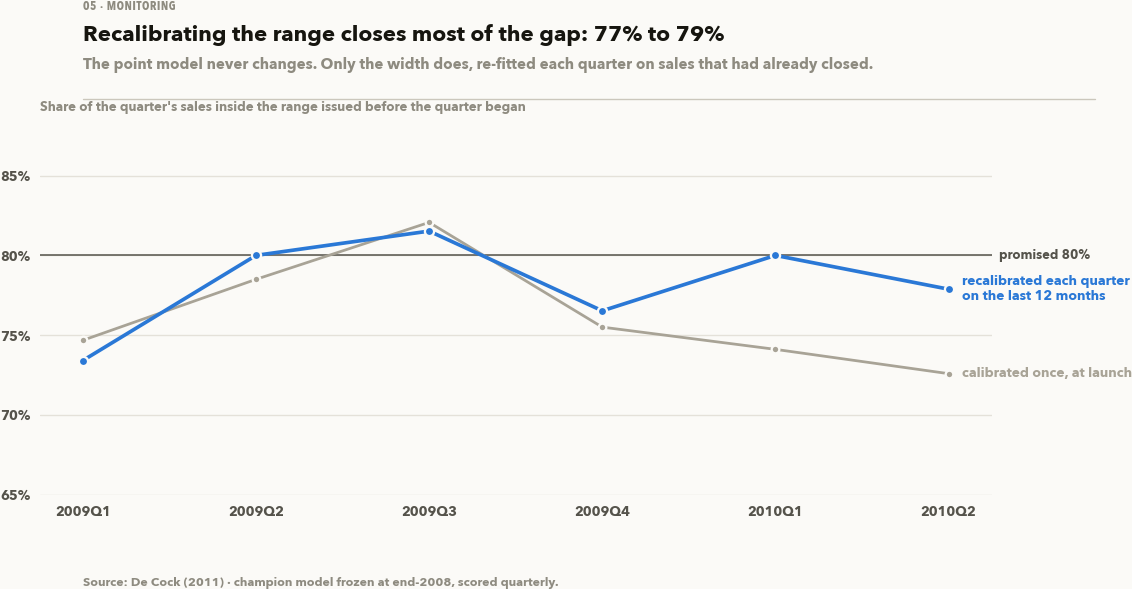

In [16]:
shown = by_quarter[by_quarter["n"] >= 30]
x = np.arange(len(shown))
nominal = 1 - CONFORMAL_ALPHA

fig, ax = plt.subplots(figsize=(10.6, 5.9))
ax.plot(x, shown[("covered", "launch")], color=CONTEXT_DARK, lw=1.8, marker="o", ms=5,
        markeredgecolor=SURFACE, markeredgewidth=1.5)
ax.plot(x, shown[("covered", "rolling")], color=SUBJECT, lw=2.4, marker="o", ms=6,
        markeredgecolor=SURFACE, markeredgewidth=1.5)
label_end(ax, x[-1], shown[("covered", "launch")].iloc[-1], "calibrated once, at launch",
          color=CONTEXT_DARK)
label_end(ax, x[-1], shown[("covered", "rolling")].iloc[-1],
          "recalibrated each quarter\non the last 12 months", color=SUBJECT)
reference_line(ax, nominal, f"promised {nominal:.0%}", color=INK_SECONDARY)
ax.set_xticks(x, shown.index)
ax.yaxis.set_major_formatter(pct)
ax.set_ylim(0.65, 0.88)
axis_note(ax, "Share of the quarter's sales inside the range issued before the quarter began")
finish(fig, f"Recalibrating the range closes most of the gap: "
            f"{recalibration['coverage_launch']:.0%} to {recalibration['coverage_rolling']:.0%}",
       "The point model never changes. Only the width does, re-fitted each quarter on sales "
       "that had already closed.")
save(fig, "05_rolling_recalibration")
plt.show()

**Rolling recalibration closes most of the coverage gap, at a small cost in width.**
Across all 862 production sales, each scored with the range it would have been issued at
the time, coverage rises from **76.7% to 78.8%** (paired 95% interval for the gain: +0.8
to +3.4 points; 25 sales move inside their range, 7 move out). Mean width rises from 21.2%
to 22.4% of value. The shortfall against the 80% promise falls from 3.3 points to 1.2.

Three details matter:

- The first quarter cannot benefit. Before 2009Q1 no production sale had closed, so the
  twelve-month window holds only 2008 launch-calibration sales. The gain arrives from
  2009Q2, and is largest in 2010, when launch coverage had drifted to 72–74%.
- The launch interval does decay here, though §4 looked flat. §4 scores the champion
  (fitted on all of 2006–2008) against the launch half-width, and its quarterly coverage
  shows no clear trend. Scored consistently, using the calibration model whose residuals set
  the bands, launch coverage falls from 75.5% in 2009Q4 to 72.6% in 2010Q2, and that is
  where recalibration gains most.
- The width moves to where the market got harder. Fitted on the latest sales, the
  bands for $122–145k and $172–216k widen from 17–18% of value to 25–26%. The cheap and
  top bands barely change.

The recalibrated bands are what the service now issues. They are fitted on the 399
sales from October 2009 to July 2010 (the twelve months before the next quarter), and
the data ends in July 2010, so no later sale exists to measure them on. Their coverage
claim rests on this backtest, which is how a recalibrated interval is validated in practice,
and the model card says so.

## 8. Persist the monitoring pack

In [17]:
accuracy.to_csv(PROCESSED / "monitoring_accuracy.csv", index=False)
drift.to_csv(PROCESSED / "monitoring_drift.csv", index=False)
(PROCESSED / "monitoring_summary.json").write_text(json.dumps({
    "quarters_monitored": int(len(accuracy)),
    "mdape_first_quarter": float(accuracy["MdAPE"].iloc[0]),
    "mdape_last_quarter": float(accuracy["MdAPE"].iloc[-1]),
    "mdape_worst_quarter": float(accuracy["MdAPE"].max()),
    "worst_feature_psi_live": float(measurable["psi"].max()),
    "worst_score_psi_live": float(np.nanmax(list(score_psi.values()))),
    "live_breach": bool(any_breach(live_triggers)),
    "negative_control_breaches": int(alarm_triggers["breached"].eq(True).sum()),
    "negative_control_mdape": float(alarm["MdAPE"]),
    "negative_control_max_feature_psi": float(alarm["max_feature_psi"]),
    "challenger_win_rate": decision["challenger_win_rate"],
    "challenger_promoted": decision["promote"],
    "interval_coverage_launch": recalibration["coverage_launch"],
    "interval_coverage_rolling": recalibration["coverage_rolling"],
}, indent=2))

# The interval the service issues from now on: bands re-fitted on the four quarters before
# the next quarter begins, i.e. on the latest closed sales. The data ends in July 2010, so
# no later sale exists to score them on; their coverage claim is the backtest above,
# which is how a recalibrated interval is validated in practice.
serve_from = (cal_pool["sale_date"].max().to_period("Q") + 1).start_time
serve_window = trailing_window(serve_from)
served_bands = mondrian(serve_window)
rolling_rows = issued[issued["calibration"] == "rolling"]
(PROCESSED / "recalibration.json").write_text(json.dumps({
    **served_bands.to_dict(),
    "relative_width_by_band": [float(np.exp(q) - np.exp(-q))
                               for q in served_bands.to_dict()["q_by_band"]],
    "window_months": RECAL_WINDOW_MONTHS,
    "window_start": str(serve_window["sale_date"].min().date()),
    "window_end": str(serve_window["sale_date"].max().date()),
    "window_n": int(len(serve_window)),
    # Mean width the served bands give the production book -- one comparable figure.
    "relative_width": float(np.mean(np.exp(served_bands.half_width(rolling_rows["log_pred"]))
                                    - np.exp(-served_bands.half_width(rolling_rows["log_pred"])))),
    "backtest": {
        **recalibration,
        "coverage_by_band": rolling_rows.groupby("band")["covered"].mean().round(6).tolist(),
        "n_by_band": rolling_rows.groupby("band").size().tolist(),
        "coverage_by_quarter": {q: float(v) for q, v in
                                rolling_rows.groupby("quarter")["covered"].mean().items()},
    },
}, indent=2))

# Each production sale with the range it would have been issued at the time -- what
# notebook 10 checks the report's promise against.
rolling_rows.assign(
    predicted=np.exp(rolling_rows["log_pred"]),
    value_low=np.exp(rolling_rows["log_pred"] - rolling_rows["q"]),
    value_high=np.exp(rolling_rows["log_pred"] + rolling_rows["q"]),
    actual=np.exp(rolling_rows["log_actual"]),
).drop(columns=["calibration"]).to_parquet(PROCESSED / "recalibrated_intervals.parquet")

print(f"served bands: trailing {RECAL_WINDOW_MONTHS} months to {serve_window['sale_date'].max():%Y-%m} "
      f"({len(serve_window)} sales)")
print(pd.DataFrame({
    "valuation from": np.exp(served_bands.edges_[:-1]).round(-3),
    "valuation to": np.exp(served_bands.edges_[1:]).round(-3),
    "range, % of value": [np.exp(q) - np.exp(-q) for q in served_bands.to_dict()["q_by_band"]],
    "launch range": [np.exp(q) - np.exp(-q) for q in launch_bands.to_dict()["q_by_band"]],
}).round(4).to_string())
print("\nwrote monitoring_accuracy.csv, monitoring_drift.csv, monitoring_summary.json,")
print("      recalibration.json, recalibrated_intervals.parquet")

served bands: trailing 12 months to 2010-07 (399 sales)
   valuation from  valuation to  range, % of value  launch range
0         61000.0      122000.0             0.2992        0.2965
1        122000.0      145000.0             0.2582        0.1767
2        145000.0      172000.0             0.2089        0.1923
3        172000.0      216000.0             0.2515        0.1704
4        216000.0      437000.0             0.2314        0.2278

wrote monitoring_accuracy.csv, monitoring_drift.csv, monitoring_summary.json,
      recalibration.json, recalibrated_intervals.parquet


## 9. What this would look like in production

| Frequency | Check | Owner |
|---|---|---|
| **Daily** | Input PSI on the scoring feed; volume and null-rate checks | Automated |
| **Monthly** | Score PSI; valuation distribution vs. development | Model owner |
| **Quarterly** | Accuracy and interval coverage once sale prices settle; recalibrate the interval bands on the trailing twelve months; full trigger pack | Model owner, reported to risk |
| **Annually, or on breach** | Full revalidation against SR 11-7 | Independent validation |

### Summary

| Finding | Consequence |
|---|---|
| PSI flags large shifts on features that change by definition, and on samples too small to measure | Both guarded in code: time features excluded by name, 5 bins instead of 10 |
| Five of the six controls fire on the non-market population | The controls can detect a different population, so their silence on the live book is informative |
| Quarterly retraining does not earn promotion here | More data did not produce a better model; promotion is decided by the pre-set rule, not by the average |
| Accuracy is measurable only *after* prices settle | Input drift is the early warning; accuracy is the confirmation |
| Recalibrating the interval each quarter lifts coverage 76.7% → 78.8% | The point model stays frozen; the bands the service issues are re-fitted on the latest twelve months |